In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

In [17]:
df = pd.read_csv("credit_card_transactions.csv")

print(df.shape)
df.head()

(1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [18]:
df = df.drop(columns=[
    "Unnamed: 0",
    "first",
    "last",
    "street",
    "cc_num",
    "trans_num",
    "merchant",
    "job",
    "city",
    "merch_zipcode"
], errors="ignore")

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["month"] = df["trans_date_trans_time"].dt.month

df["age"] = df["trans_date_trans_time"].dt.year - df["dob"].dt.year

df = df.drop(columns=["trans_date_trans_time", "dob"])

df = df.dropna()

print(df.shape)
df.head()

(1296675, 16)


,category,amt,gender,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day_of_week,month,age
0,misc_net,4.97,F,NC,28654,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,31
1,grocery_pos,107.23,F,WA,99160,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,41
2,entertainment,220.11,M,ID,83252,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,57
3,gas_transport,45.00,M,MT,59632,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,52
4,misc_pos,41.96,M,VA,24433,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,33


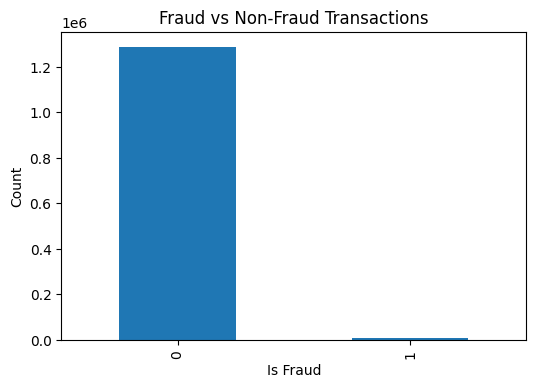

In [19]:
df["is_fraud"].value_counts()

df["is_fraud"].value_counts(normalize=True)

plt.figure(figsize=(6,4))
df["is_fraud"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

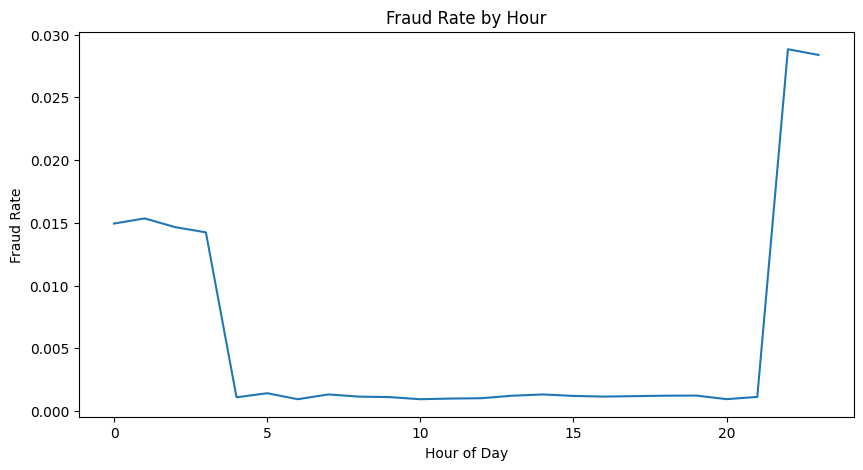

In [20]:
fraud_by_hour = df.groupby("hour")["is_fraud"].mean()

plt.figure(figsize=(10,5))
plt.plot(fraud_by_hour.index, fraud_by_hour.values)
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour")
plt.show()

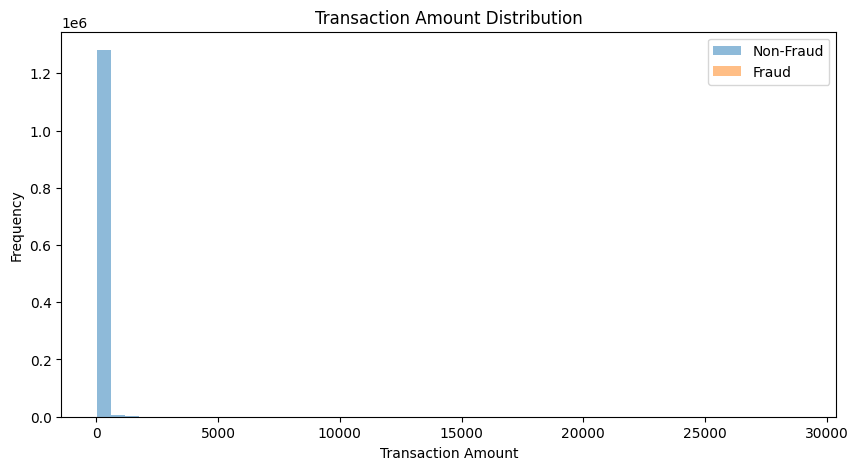

In [21]:
plt.figure(figsize=(10,5))

plt.hist(df[df["is_fraud"] == 0]["amt"], bins=50, alpha=0.5, label="Non-Fraud")
plt.hist(df[df["is_fraud"] == 1]["amt"], bins=50, alpha=0.5, label="Fraud")

plt.legend()
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.show()

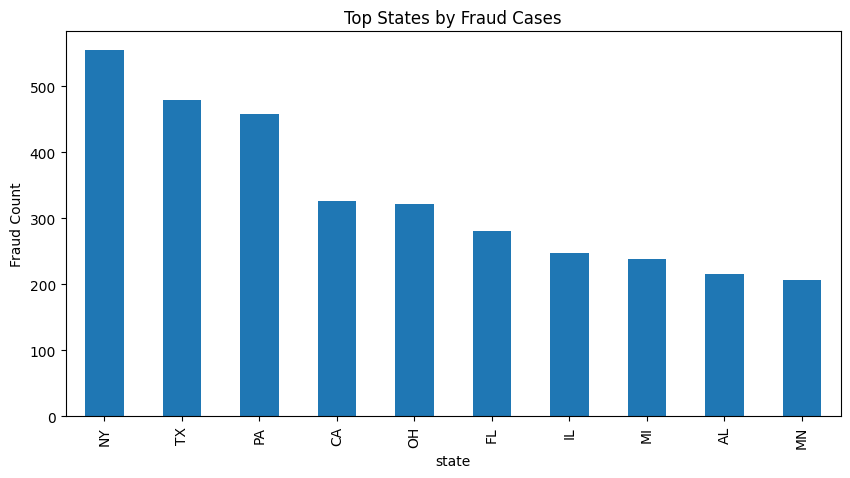

In [22]:
fraud_states = (
    df[df["is_fraud"] == 1]
    .groupby("state")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
fraud_states.plot(kind="bar")
plt.title("Top States by Fraud Cases")
plt.ylabel("Fraud Count")
plt.show()

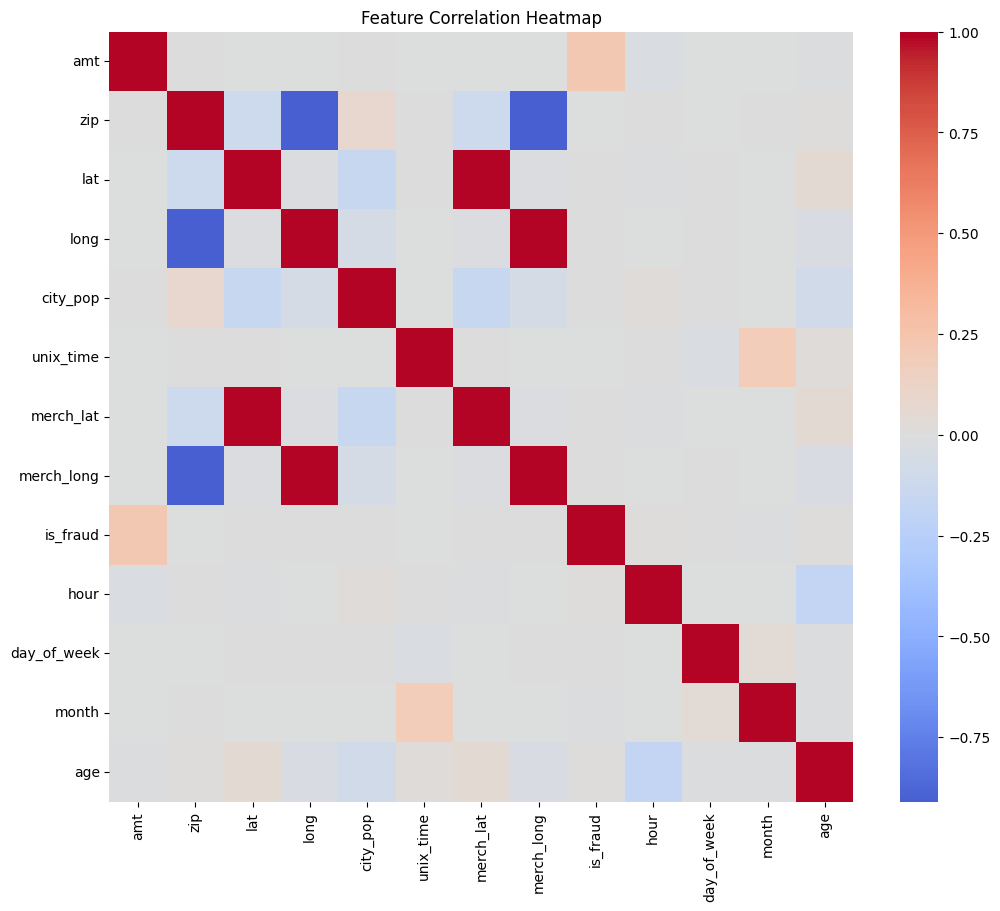

In [23]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
df_model = pd.get_dummies(
    df,
    columns=["category", "gender", "state"],
    drop_first=True
)

X = df_model.drop("is_fraud", axis=1)
y = df_model["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1037340, 76)
(259335, 76)


In [25]:
def evaluate_model(model_name, y_test, y_pred, y_prob=None):
    print(model_name)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    if y_prob is not None:
        print("ROC-AUC Score:")
        print(roc_auc_score(y_test, y_prob))

In [26]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("LOGISTIC REGRESSION RESULTS", y_test, log_preds, log_probs)

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    257834
           1       0.04      0.76      0.07      1501

    accuracy                           0.88    259335
   macro avg       0.52      0.82      0.50    259335
weighted avg       0.99      0.88      0.93    259335

Confusion Matrix:
[[227651  30183]
 [   356   1145]]
ROC-AUC Score:
0.9151239594184561


In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("RANDOM FOREST RESULTS", y_test, rf_preds, rf_probs)

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.98      0.73      0.84      1501

    accuracy                           1.00    259335
   macro avg       0.99      0.86      0.92    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
[[257816     18]
 [   406   1095]]
ROC-AUC Score:
0.9929041723114775


In [28]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)
gb_probs = gb_model.predict_proba(X_test)[:, 1]

evaluate_model("GRADIENT BOOSTING RESULTS", y_test, gb_preds, gb_probs)

GRADIENT BOOSTING RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.83      0.69      0.75      1501

    accuracy                           1.00    259335
   macro avg       0.91      0.85      0.88    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
[[257616    218]
 [   463   1038]]
ROC-AUC Score:
0.97322857622418


In [29]:
iso_model = IsolationForest(
    contamination=y_train.mean(),
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train_scaled)

iso_preds_raw = iso_model.predict(X_test_scaled)

iso_preds = np.where(iso_preds_raw == -1, 1, 0)

evaluate_model("ISOLATION FOREST RESULTS", y_test, iso_preds)

ISOLATION FOREST RESULTS
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    257834
           1       0.09      0.09      0.09      1501

    accuracy                           0.99    259335
   macro avg       0.54      0.54      0.54    259335
weighted avg       0.99      0.99      0.99    259335

Confusion Matrix:
[[256514   1320]
 [  1373    128]]


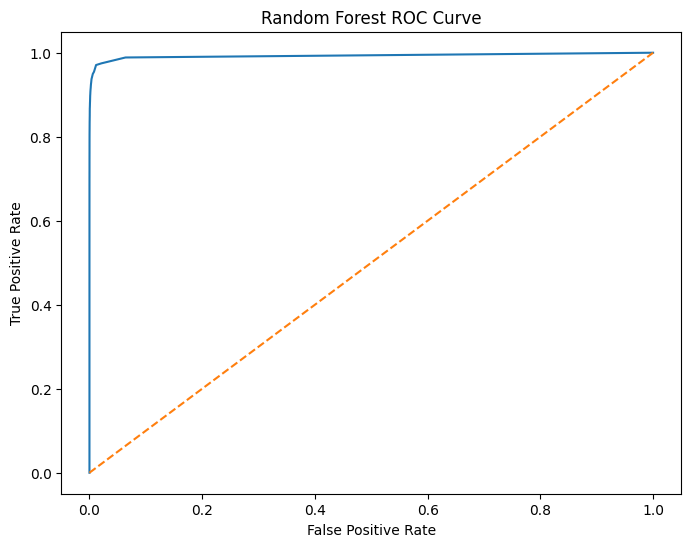

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.show()

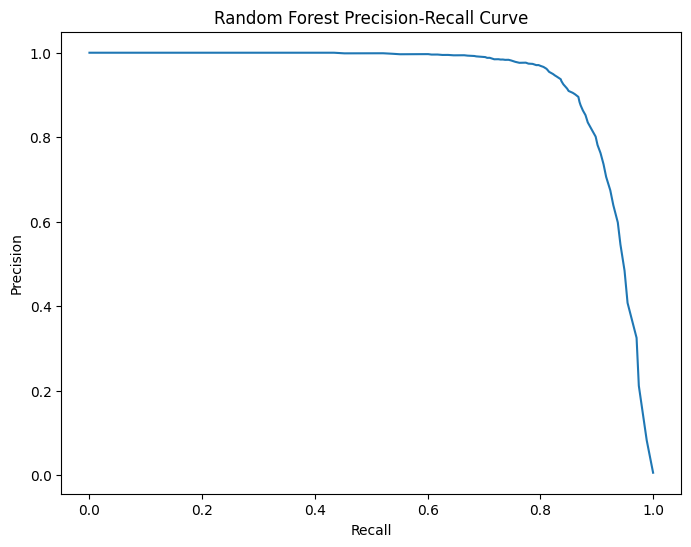

In [31]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.show()

In [32]:
custom_preds = (rf_probs > 0.3).astype(int)

print("RANDOM FOREST WITH 0.3 THRESHOLD")
print(classification_report(y_test, custom_preds))
print(confusion_matrix(y_test, custom_preds))

RANDOM FOREST WITH 0.3 THRESHOLD
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.95      0.82      0.88      1501

    accuracy                           1.00    259335
   macro avg       0.97      0.91      0.94    259335
weighted avg       1.00      1.00      1.00    259335

[[257768     66]
 [   266   1235]]


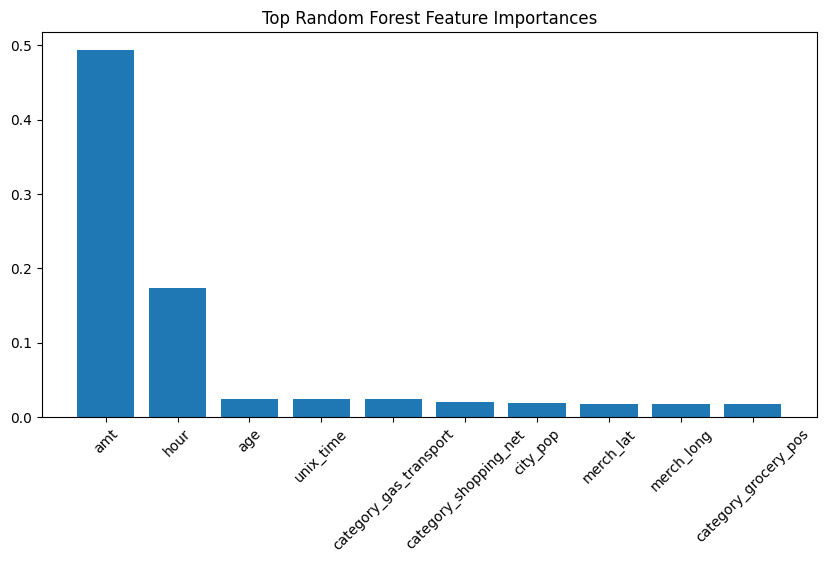

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_features["Feature"], top_features["Importance"])
plt.xticks(rotation=45)
plt.title("Top Random Forest Feature Importances")
plt.show()

In [34]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Isolation Forest"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, gb_probs),
        np.nan
    ]
})

comparison

,Model,ROC-AUC
0,Logistic Regression,0.915124
1,Random Forest,0.992904
2,Gradient Boosting,0.973229
3,Isolation Forest,NaN
